```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [224]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import wfdb
import os
import re
import dotenv

import matplotlib.pyplot as plt

In [ ]:
dotenv.load_dotenv('../.env')

In [ ]:
BASE_DIR = os.getenv('ECG_DIR')
HEA_DIR = os.path.join(BASE_DIR,
                       'physionet_classification_challenge',
                       'training',
                       'cpsc_2018', 
                       'g1')

SAMPLE_RATE = 500

In [ ]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [243]:
ecg_path = hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [244]:
re_age = re.compile(r'Age:\s?(\d+)') 
re_sex = re.compile(r'Sex:\s?(\w+)')
re_diagnosis = re.compile(r'Dx:\s?([0-9]+)')

age  = int(re.findall(re_age, meta_str)[0])
sex = re.findall(re_sex, meta_str)[0]
diagnosis = re.findall(re_diagnosis, meta_str)[0]

print(f"Age:{age},\nSex:{sex},\nDiagnosis:{diagnosis}")

Age:63,
Sex:Female,
Diagnosis:164884008


In [245]:
tmp = wfdb.rdsamp(ecg_path)[0]
tdf = pd.DataFrame(tmp, columns=band_names)
tdf['patient'] = hea
tdf['age'] = age
tdf['sex'] = sex
tdf['diagnosis'] = diagnosis
tdf['segment'] = hea

In [246]:
band_names

['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [255]:
BAND = 'II'

In [256]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

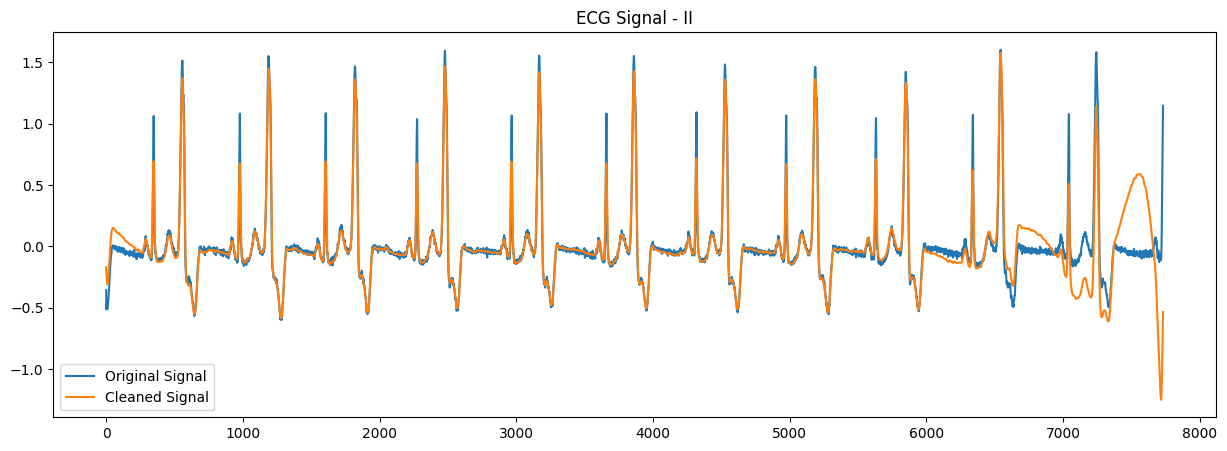

In [257]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [258]:
peaks, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks, sampling_rate=SAMPLE_RATE, show=False)

peak_features_nonlinear = nk.hrv_nonlinear(peaks, 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False)

peak_features_frequency = nk.hrv_frequency(peaks, sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True)
                                        

/media/bramiozo/Storage1/bramiozo/VIRTUALENVS/Python/timex--LThe9rE-py3.12/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:529: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/media/bramiozo/Storage1/bramiozo/VIRTUALENVS/Python/timex--LThe9rE-py3.12/lib/python3.12/site-packages/neurokit2/complexity/entropy_multiscale.py:349: RuntimeWarning: invalid value encountered in scalar divide
  mse = np.trapz(mse) / len(mse)


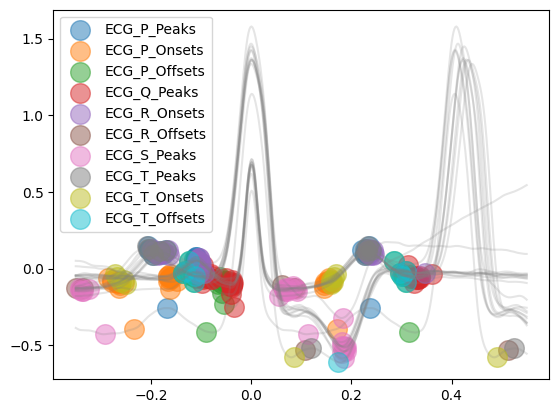

In [259]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="dwt",
                                 show=True,
                                 show_type='all')

In [252]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

ecg_rsp = nk.ecg_rsp(ecg_rates, method='vangent2019', sampling_rate=SAMPLE_RATE)

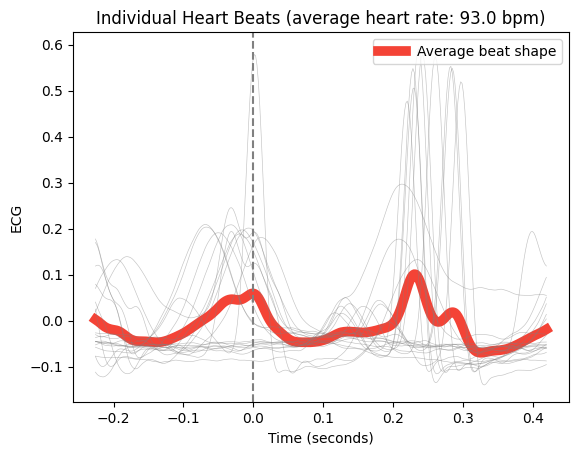

In [253]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=True);

In [254]:
quality_string

'Excellent'